In [1]:
import pandas as pd

from benchmarking.metrics.base_metrics import (
    compute_precision_recall_data,
    load_all_feature_tables,
    compute_r2_values_for_plasma_spikein,
)

from benchmarking.plots import plot_specific_pr_curves, plot_r2_distribution
import matplotlib.pyplot as plt

# Load in data

In [2]:
nist_groundtruth_library_data = pd.read_parquet(
    "../data/library_spectra/nist_srm_spikein_lib.pq"
)

In [3]:
# Building the feature table for reframe_spikein_dataset
merged_feature_tables = load_all_feature_tables(
    ["../data/groundtruth_dataset/NIST_SRM"],
    annotation_subfolder="annotated_spectral_entropy",
)

100%|██████████| 1/1 [00:00<00:00,  5.68it/s]


# Overview plot with recall curve and R2 distribution

In [4]:
score_range, precision_recall_curves, confusion_matrix_data = (
    compute_precision_recall_data(
        merged_feature_tables=merged_feature_tables,
        ground_truth_data=nist_groundtruth_library_data,
        score_threshold=0.7,
    )
)

Number of unique true InChIKeys (14-character): 75


In [5]:
r2_values = compute_r2_values_for_plasma_spikein(
    merged_feature_tables=merged_feature_tables,
    groundtruth_data=nist_groundtruth_library_data,
    threshold=0.7,
)

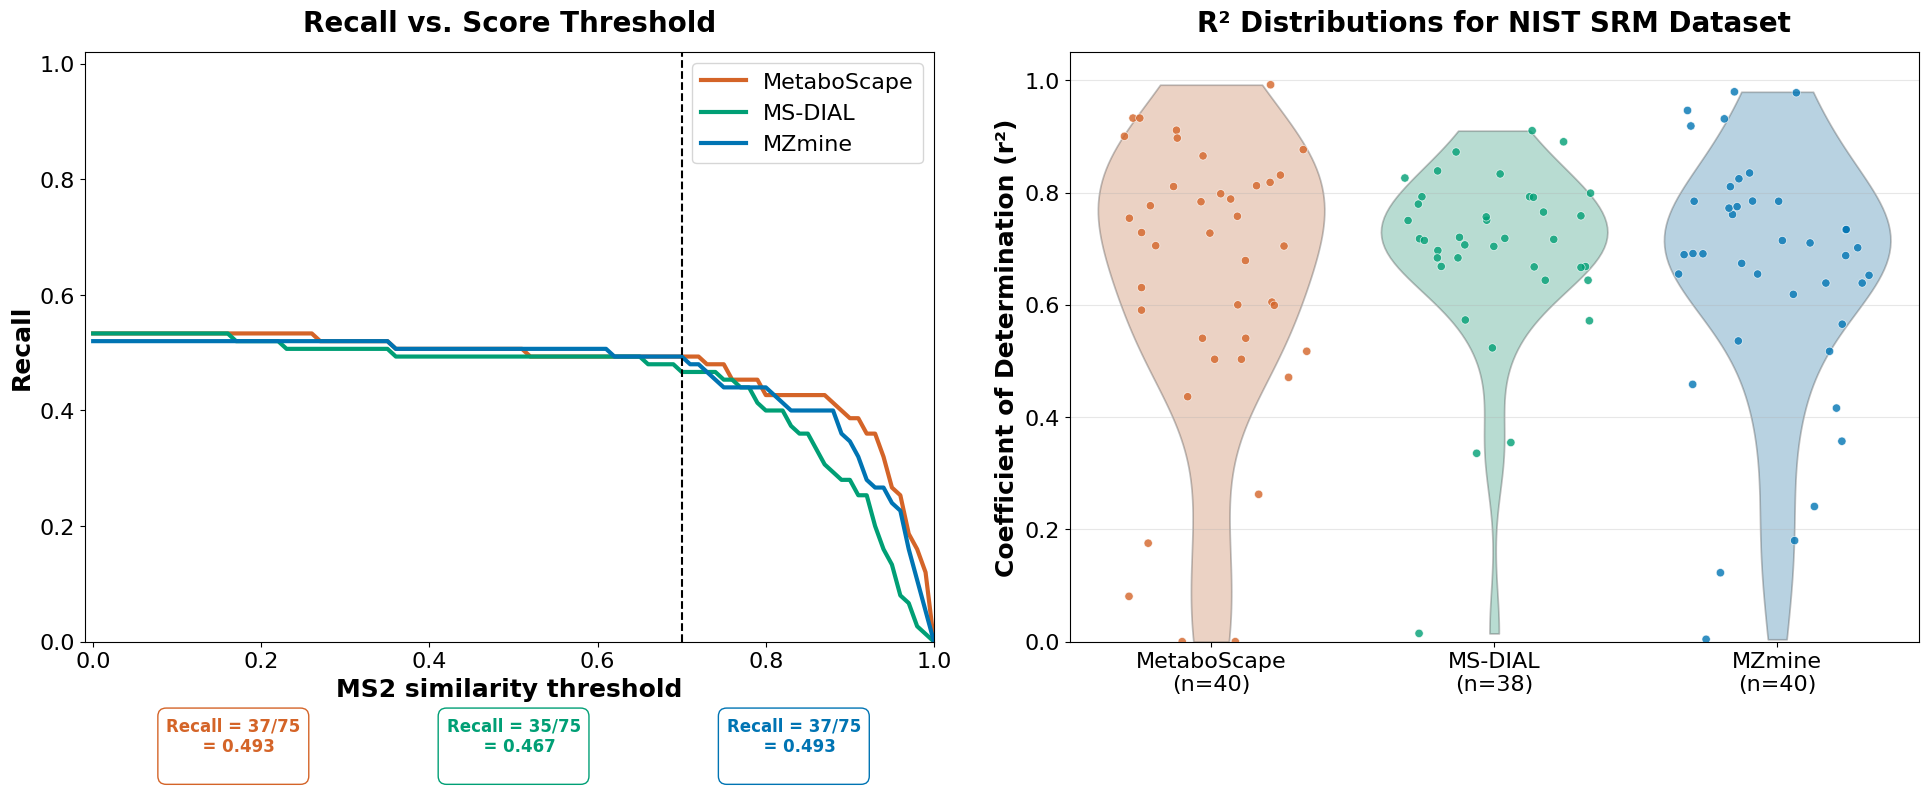

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(20, 8))

plot_specific_pr_curves(
    score_range,
    precision_recall_curves,
    confusion_matrix_data,
    x_var="score",
    y_var="recall",
    confusion_matrix_threshold=0.7,
    title="Recall vs. Score Threshold",
    fig_size=(10, 8),
    ax=axes[0],
)

plot_r2_distribution(
    r2_values,
    significant_only=False,
    significance_threshold=0.05,
    title="R² Distributions for NIST SRM Dataset",
    figsize=(10, 8),
    ax=axes[1],
)

# add spacing between subplots and save the combined figure
fig.subplots_adjust(wspace=10)

plt.tight_layout()
plt.savefig("../figures/figure_4.png", dpi=400, bbox_inches="tight")
plt.show()